In [78]:
import pandas as pd
import matplotlib.pyplot as plt

In [79]:
df=pd.read_csv('cardekho_data.csv')
df.head()

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


In [80]:
df.isnull().sum()

Car_Name         0
Year             0
Selling_Price    0
Present_Price    0
Kms_Driven       0
Fuel_Type        0
Seller_Type      0
Transmission     0
Owner            0
dtype: int64

In [81]:
df["Car_Name"].value_counts()

Car_Name
city                        26
corolla altis               16
verna                       14
fortuner                    11
brio                        10
                            ..
Honda CB Trigger             1
Yamaha FZ S                  1
Bajaj Pulsar 135 LS          1
Activa 4g                    1
Bajaj Avenger Street 220     1
Name: count, Length: 98, dtype: int64

In [82]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df["Fuel_Type"] = le.fit_transform(df["Fuel_Type"])
df["Seller_Type"] = le.fit_transform(df["Seller_Type"])
df["Transmission"] = le.fit_transform(df["Transmission"])
df.head()

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,2,0,1,0
1,sx4,2013,4.75,9.54,43000,1,0,1,0
2,ciaz,2017,7.25,9.85,6900,2,0,1,0
3,wagon r,2011,2.85,4.15,5200,2,0,1,0
4,swift,2014,4.60,6.87,42450,1,0,1,0


In [83]:
df.describe()

,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
count,301.000000,301.000000,301.000000,301.000000,301.000000,301.000000,301.000000,301.000000
mean,2013.627907,4.661296,7.628472,36947.205980,1.787375,0.352159,0.867110,0.043189
std,2.891554,5.082812,8.644115,38886.883882,0.425801,0.478439,0.340021,0.247915
min,2003.000000,0.100000,0.320000,500.000000,0.000000,0.000000,0.000000,0.000000
25%,2012.000000,0.900000,1.200000,15000.000000,2.000000,0.000000,1.000000,0.000000
50%,2014.000000,3.600000,6.400000,32000.000000,2.000000,0.000000,1.000000,0.000000
75%,2016.000000,6.000000,9.900000,48767.000000,2.000000,1.000000,1.000000,0.000000
max,2018.000000,35.000000,92.600000,500000.000000,2.000000,1.000000,1.000000,3.000000


Year                Axes(0.125,0.653529;0.227941x0.226471)
Selling_Price    Axes(0.398529,0.653529;0.227941x0.226471)
Present_Price    Axes(0.672059,0.653529;0.227941x0.226471)
Kms_Driven          Axes(0.125,0.381765;0.227941x0.226471)
Fuel_Type        Axes(0.398529,0.381765;0.227941x0.226471)
Seller_Type      Axes(0.672059,0.381765;0.227941x0.226471)
Transmission            Axes(0.125,0.11;0.227941x0.226471)
Owner                Axes(0.398529,0.11;0.227941x0.226471)
dtype: object

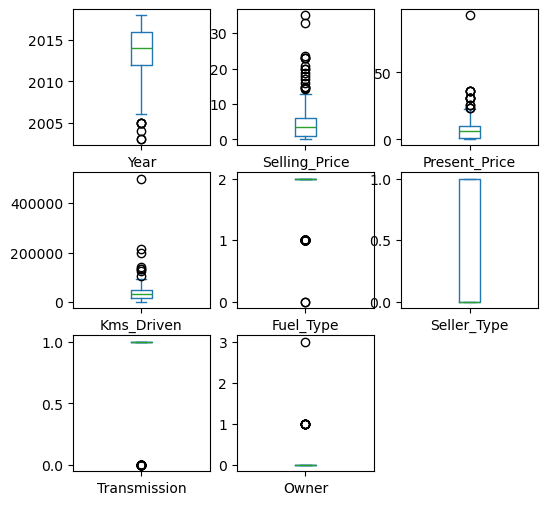

In [84]:
df.plot(kind='box', subplots=True, layout=(3,3), figsize=(6,6))

In [85]:
def get_brand(name):
    name = name.lower()
    # Honda
    if any(x in name for x in ["city", "brio", "amaze", "jazz", "honda"]):
        return "Honda"

    # Hyundai
    elif any(x in name for x in ["verna", "i20", "i10", "eon", "grand","creta", "xcent", "elantra"]):
        return "Hyundai"

    # Toyota
    elif any(x in name for x in ["corolla", "fortuner", "innova","etios", "camry"]):
        return "Toyota"

    # Maruti Suzuki
    elif any(x in name for x in ["swift", "ciaz", "alto", "ertiga","sx4", "ritz", "wagon", "dzire","baleno", "vitara", "omni","ignis", "800", "suzuki"]):
        return "Maruti"

    # Bikes
    elif "bajaj" in name:
        return "Bajaj"

    elif "royal" in name:
        return "Royal Enfield"

    elif "hero" in name:
        return "Hero"

    elif "yamaha" in name:
        return "Yamaha"

    elif "tvs" in name:
        return "TVS"

    elif "ktm" in name:
        return "KTM"

    elif "activa" in name:
        return "Honda"

    elif "mahindra" in name:
        return "Mahindra"

    elif "land" in name:
        return "Land Rover"

    elif "um" in name:
        return "UM"

    else:
        return name.split()[0].capitalize()

In [86]:
df["Brand"] = df["Car_Name"].apply(get_brand)

df.drop("Car_Name", axis=1, inplace=True)
df.head()

,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner,Brand
0,2014,3.35,5.59,27000,2,0,1,0,Maruti
1,2013,4.75,9.54,43000,1,0,1,0,Maruti
2,2017,7.25,9.85,6900,2,0,1,0,Maruti
3,2011,2.85,4.15,5200,2,0,1,0,Maruti
4,2014,4.60,6.87,42450,1,0,1,0,Maruti


In [87]:
df["Brand"].value_counts()

Brand
Honda            72
Maruti           50
Hyundai          50
Toyota           49
Bajaj            25
Royal Enfield    17
Hero             13
Yamaha            8
TVS               8
KTM               4
S                 1
Land Rover        1
UM                1
Hyosung           1
Mahindra          1
Name: count, dtype: int64

In [88]:
print(df["Kms_Driven"].max())

500000


In [89]:
df = df[df["Kms_Driven"] < 300000]

In [90]:
df.head()

,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner,Brand
0,2014,3.35,5.59,27000,2,0,1,0,Maruti
1,2013,4.75,9.54,43000,1,0,1,0,Maruti
2,2017,7.25,9.85,6900,2,0,1,0,Maruti
3,2011,2.85,4.15,5200,2,0,1,0,Maruti
4,2014,4.60,6.87,42450,1,0,1,0,Maruti


In [91]:
df["Brand"].value_counts()

Brand
Honda            71
Maruti           50
Hyundai          50
Toyota           49
Bajaj            25
Royal Enfield    17
Hero             13
Yamaha            8
TVS               8
KTM               4
S                 1
Land Rover        1
UM                1
Hyosung           1
Mahindra          1
Name: count, dtype: int64

In [92]:
le_brand=LabelEncoder()
df["Brand"] = le_brand.fit_transform(df["Brand"])

C:\Users\nikit\AppData\Local\Temp\ipykernel_14572\2254316211.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["Brand"] = le_brand.fit_transform(df["Brand"])


In [93]:
from sklearn.model_selection import train_test_split
X = df.drop("Selling_Price", axis=1)
y = df["Selling_Price"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
from sklearn.ensemble import RandomForestRegressor
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [94]:
predict=model.predict(X_test)
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
mae = mean_absolute_error(y_test, predict)
mse = mean_squared_error(y_test, predict)
r2 = r2_score(y_test, predict)
print(f"Mean Absolute Error: {mae}")
print(f"Mean Squared Error: {mse}")
print(f"R^2 Score: {r2}")
print("Training score:", model.score(X_train, y_train))
print("Testing score:", model.score(X_test, y_test))

Mean Absolute Error: 0.6173516666666671
Mean Squared Error: 0.8057301715000005
R^2 Score: 0.9664733156717591
Training score: 0.9838051279712933
Testing score: 0.9664733156717591
